# Exercícios — Vetores, Matrizes e Projeções

**Tema:** Álgebra Linear e Otimização › Vetores, Matrizes e Projeções

Resolva antes de olhar o gabarito. A estrutura é sempre a mesma: enunciado,
célula de resposta, gabarito comentado.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(55)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Normas e a armadilha da escala

Um cliente é descrito por `(idade_anos, renda_mil_reais, n_compras)`. Calcule
a distância euclidiana entre os clientes A = `(25, 3.0, 40)` e
B = `(45, 3.5, 42)`. Depois calcule qual fração da distância ao quadrado vem
de cada variável. Qual variável domina, e é porque ela é a mais "importante"?

In [2]:
a = np.array([25.0, 3.0, 40.0])
b = np.array([45.0, 3.5, 42.0])

# --- sua resposta ---

### Gabarito 1

In [3]:
diferenca = b - a
distancia = np.linalg.norm(diferenca)
contribuicao = diferenca**2 / (diferenca**2).sum()

print(f"distância euclidiana total: {distancia:.4f}\n")
for nome, d, c in zip(["idade", "renda", "n_compras"], diferenca, contribuicao):
    print(f"{nome:<12s} diferença = {d:>6.2f}   contribui {c:>6.1%} da distância²")

distância euclidiana total: 20.1060

idade        diferença =  20.00   contribui  98.9% da distância²
renda        diferença =   0.50   contribui   0.1% da distância²
n_compras    diferença =   2.00   contribui   1.0% da distância²


**Resposta:** `idade` domina (diferença de 20 anos vs. 0,5 mil reais vs. 2
compras). Isso **não** significa que idade é a variável mais importante para
prever comportamento — significa apenas que a unidade "anos" produz números
maiores que "milhares de reais". Sem padronizar, qualquer método baseado em
distância (k-NN, k-means, PCA) vai pesar as variáveis pelas suas unidades, não
pelo seu conteúdo informativo.

---
## Exercício 2 🟢 — Cosseno vs. distância euclidiana

Dados os vetores de contagem de palavras abaixo (mesmo vocabulário de 4
termos), calcule a matriz de similaridade de cosseno e a matriz de distância
euclidiana entre os três documentos. Qual par a distância euclidiana classifica
como "mais parecido" e qual par o cosseno classifica como mais parecido? Qual
dos dois faz mais sentido para o conteúdo dos documentos?

In [4]:
doc_curto = np.array([1, 2, 0, 1])       # documento curto sobre esporte
doc_longo = np.array([4, 9, 1, 5])       # documento longo, mesmo assunto (esporte)
doc_outro = np.array([0, 1, 6, 0])       # documento curto, assunto diferente

# --- sua resposta ---

### Gabarito 2

In [5]:
docs = {"curto (esporte)": doc_curto, "longo (esporte)": doc_longo,
        "outro assunto": doc_outro}
nomes = list(docs)
M = np.array([docs[k] for k in nomes], dtype=float)

normas = np.linalg.norm(M, axis=1, keepdims=True)
cos_sim = (M / normas) @ (M / normas).T
dist_euc = np.linalg.norm(M[:, None, :] - M[None, :, :], axis=2)

print("cosseno:")
print(f"{'':<20s}" + "".join(f"{n:>18s}" for n in nomes))
for i, n in enumerate(nomes):
    print(f"{n:<20s}" + "".join(f"{v:>18.3f}" for v in cos_sim[i]))

print("\ndistância euclidiana:")
print(f"{'':<20s}" + "".join(f"{n:>18s}" for n in nomes))
for i, n in enumerate(nomes):
    print(f"{n:<20s}" + "".join(f"{v:>18.3f}" for v in dist_euc[i]))

cosseno:
                       curto (esporte)   longo (esporte)     outro assunto
curto (esporte)                  1.000             0.994             0.134
longo (esporte)                  0.994             1.000             0.222
outro assunto                    0.134             0.222             1.000

distância euclidiana:
                       curto (esporte)   longo (esporte)     outro assunto
curto (esporte)                  0.000             8.660             6.245
longo (esporte)                  8.660             0.000            11.402
outro assunto                    6.245            11.402             0.000


**Resposta:** o cosseno aponta "curto (esporte)" e "longo (esporte)" como os
mais parecidos (cosseno perto de 1) — o correto, já que são o mesmo assunto.
A distância euclidiana, por outro lado, pode colocar "curto (esporte)" mais
perto de "outro assunto" simplesmente porque ambos têm contagens totais
pequenas. A distância euclidiana confunde **tamanho do documento** com
**assunto**; o cosseno separa as duas coisas.

---
## Exercício 3 🟡 — Diagnosticando posto e condicionamento

Para cada uma das três matrizes abaixo, calcule o posto e o número de
condição, e classifique como: (a) bem condicionada, (b) mal condicionada mas
posto cheio, ou (c) posto deficiente.

In [6]:
n = 150
z = rng.normal(0, 1, n)

M1 = np.column_stack([rng.normal(0, 1, n), rng.normal(0, 1, n), rng.normal(0, 1, n)])
M2 = np.column_stack([z, z + rng.normal(0, 0.001, n), rng.normal(0, 1, n)])
M3 = np.column_stack([z, 3 * z, rng.normal(0, 1, n)])

# --- sua resposta ---

### Gabarito 3

In [7]:
for nome, M in [("M1", M1), ("M2", M2), ("M3", M3)]:
    posto = np.linalg.matrix_rank(M)
    cond = np.linalg.cond(M)
    if posto < M.shape[1]:
        classe = "(c) posto deficiente"
    elif cond > 1e3:
        classe = "(b) mal condicionada, posto cheio"
    else:
        classe = "(a) bem condicionada"
    print(f"{nome}: posto={posto}  condição={cond:>12.3e}   -> {classe}")

M1: posto=3  condição=   1.315e+00   -> (a) bem condicionada
M2: posto=3  condição=   2.248e+03   -> (b) mal condicionada, posto cheio
M3: posto=2  condição=   2.362e+16   -> (c) posto deficiente


**M1** tem três colunas independentes geradas separadamente: bem condicionada.
**M2** tem duas colunas *quase* idênticas (`z` e `z` com ruído de 0,001): posto
numericamente cheio, mas condição altíssima — a armadilha que não aparece só
olhando o posto. **M3** tem a segunda coluna como múltiplo exato da primeira
($3z$): dependência linear exata, posto deficiente de verdade.

---
## Exercício 4 🟡 — Projeção sobre uma reta, na mão

Projete $y = (4, 3)$ sobre a direção de $a = (1, 2)$. Calcule o coeficiente da
projeção, o vetor projetado $\hat y$, o resíduo, e verifique numericamente que
o resíduo é ortogonal a $a$. Depois plote os três vetores.

In [8]:
a = np.array([1.0, 2.0])
y = np.array([4.0, 3.0])

# --- sua resposta ---

### Gabarito 4

coeficiente = 2.0000
y_hat       = [2. 4.]
resíduo     = [ 2. -1.]
<a, resíduo> = 0.00e+00   <- ortogonal, como esperado


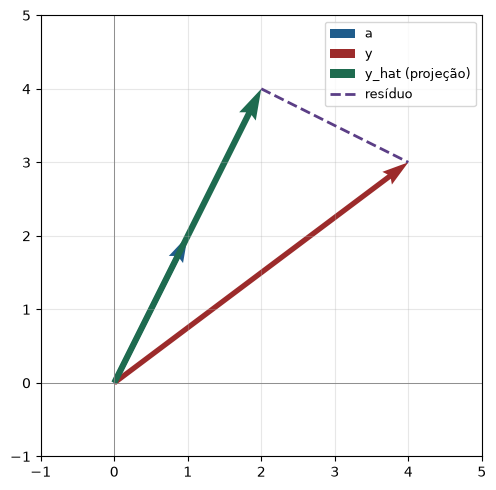

In [9]:
coef = np.dot(a, y) / np.dot(a, a)
y_hat = coef * a
residuo = y - y_hat

print(f"coeficiente = {coef:.4f}")
print(f"y_hat       = {y_hat}")
print(f"resíduo     = {residuo}")
print(f"<a, resíduo> = {np.dot(a, residuo):.2e}   <- ortogonal, como esperado")

fig, ax = plt.subplots(figsize=(6, 5))
ax.quiver(0, 0, *a, angles="xy", scale_units="xy", scale=1, color=AZUL, width=0.012, label="a")
ax.quiver(0, 0, *y, angles="xy", scale_units="xy", scale=1, color=VERMELHO, width=0.012, label="y")
ax.quiver(0, 0, *y_hat, angles="xy", scale_units="xy", scale=1, color=VERDE, width=0.014,
          label="y_hat (projeção)")
ax.plot([y_hat[0], y[0]], [y_hat[1], y[1]], color=ROXO, lw=2, ls="--", label="resíduo")
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

---
## Exercício 5 🟡 — Regressão via QR vs. equações normais em condição alta

Construa `X` com 4 colunas e número de condição controlado (~$10^7$), usando
a mesma técnica de `U @ diag(s) @ V.T` do notebook-guia. Gere `y = X @ beta`
exatamente (sem ruído) e recupere `beta` por (a) equações normais
`inv(X.T@X) @ X.T@y`, (b) `np.linalg.solve(R, Q.T@y)` via QR, e (c)
`np.linalg.lstsq`. Compare o erro de cada método contra o `beta` verdadeiro.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
n, p = 300, 4
condicao_alvo = 1e7

U, _ = np.linalg.qr(rng.normal(0, 1, (n, p)))
V, _ = np.linalg.qr(rng.normal(0, 1, (p, p)))
s = np.logspace(0, -np.log10(condicao_alvo), p)
X = U @ np.diag(s) @ V.T
beta_real = rng.normal(0, 1, p)
y = X @ beta_real

beta_normal = np.linalg.inv(X.T @ X) @ X.T @ y
Q, R = np.linalg.qr(X)
beta_qr = np.linalg.solve(R, Q.T @ y)
beta_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)

print(f"número de condição de X:   {np.linalg.cond(X):.2e}")
print(f"número de condição de X'X: {np.linalg.cond(X.T @ X):.2e}\n")

for nome, b in [("equações normais", beta_normal), ("QR", beta_qr), ("lstsq (SVD)", beta_lstsq)]:
    erro = np.linalg.norm(b - beta_real)
    print(f"{nome:<20s} erro = {erro:.3e}")

número de condição de X:   1.00e+07
número de condição de X'X: 1.02e+14

equações normais     erro = 5.096e-03
QR                   erro = 2.974e-11
lstsq (SVD)          erro = 3.681e-11


**Resposta esperada:** o erro das equações normais é ordens de magnitude
maior que o de QR e lstsq, porque formar $X^\top X$ eleva o número de
condição de ~$10^7$ para ~$10^{14}$ — perto do limite de precisão do
`float64` ($\approx 10^{16}$). QR e SVD trabalham em $X$ diretamente e
preservam a condição original.

---
## Exercício 6 🔴 — Auditoria de um pipeline com vazamento de posto

Um colega monta a matriz de features assim: `idade`, `idade_em_meses`
(= idade × 12), três dummies de região (`Norte`, `Sul`, `Centro`) **sem**
`drop_first`, e uma coluna de intercepto. Ele reclama que
`np.linalg.inv(X.T @ X)` lança `LinAlgError: Singular matrix`.

1. Reproduza o problema com dados sintéticos.
2. Diagnostique **as duas** fontes de dependência linear (há duas
   independentes nesse desenho).
3. Proponha e implemente a correção mínima para cada uma.

In [12]:
# --- sua resposta ---

### Gabarito 6

In [13]:
n = 200
idade = rng.normal(35, 8, n)
idade_meses = idade * 12
regiao = rng.choice(["Norte", "Sul", "Centro"], n)
dummies = np.column_stack([(regiao == r).astype(float) for r in ["Norte", "Sul", "Centro"]])
intercepto = np.ones((n, 1))

X_problema = np.hstack([intercepto, idade[:, None], idade_meses[:, None], dummies])
print(f"shape de X: {X_problema.shape}   posto: {np.linalg.matrix_rank(X_problema)}"
      f"   (deveria ser {X_problema.shape[1]} para posto cheio)")

try:
    np.linalg.inv(X_problema.T @ X_problema)
except np.linalg.LinAlgError as e:
    print(f"\nerro reproduzido: {e}")

shape de X: (200, 6)   posto: 4   (deveria ser 6 para posto cheio)


**Diagnóstico 1 — `idade` e `idade_meses`:** são a mesma informação em escala
diferente ($idade\_meses = 12 \times idade$), uma combinação linear exata da
outra.

**Diagnóstico 2 — as 3 dummies + intercepto:** as dummies somam exatamente 1
em toda linha, que é a própria coluna de intercepto.

**Correção:** remova `idade_meses` (informação redundante, mantenha só uma
escala) e use `drop_first` nas dummies (remova uma categoria de referência).

In [14]:
X_corrigido = np.hstack([intercepto, idade[:, None], dummies[:, 1:]])  # dropa "Norte"
posto_corrigido = np.linalg.matrix_rank(X_corrigido)
print(f"shape de X corrigido: {X_corrigido.shape}   posto: {posto_corrigido}"
      f"   (posto cheio: {posto_corrigido == X_corrigido.shape[1]})")
print(f"número de condição: {np.linalg.cond(X_corrigido):.2f}")

# agora inv(X'X) funciona
_ = np.linalg.inv(X_corrigido.T @ X_corrigido)
print("inv(X.T @ X) executou sem erro.")

shape de X corrigido: (200, 4)   posto: 4   (posto cheio: True)
número de condição: 178.58
inv(X.T @ X) executou sem erro.


**A lição:** "matriz singular" quase sempre tem uma causa **estrutural** no
desenho das features, não um bug numérico aleatório. Antes de qualquer
regularização ou truque numérico, pergunte: alguma coluna é combinação exata
de outras?

---
## Fechamento

- Distância sem padronização mede unidades, não importância.
- Cosseno separa "assunto" de "tamanho"; é por isso que domina busca vetorial.
- Posto cheio não é garantia de bom condicionamento — sempre olhe as duas
  métricas juntas.
- Formar $X^\top X$ eleva o número de condição ao quadrado; QR e SVD evitam
  esse problema.
- "Matriz singular" quase sempre denuncia uma dependência linear real no
  desenho das features — procure-a antes de aplicar qualquer remendo numérico.

→ Próximo módulo: **Decomposições — SVD, Autovalores e PCA**.